# Power comparison in a normal means problem

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from seaborn import color_palette
from scipy.stats import norm
import seaborn as sns
from pthin import pthin

In [7]:
rng = np.random.default_rng(42)
def two_sided_pval(x):
    return 2 * (1 - norm.cdf(np.abs(x)))

def one_sided_pval(x):
    return (1 - norm.cdf(x))

## p-value distribution

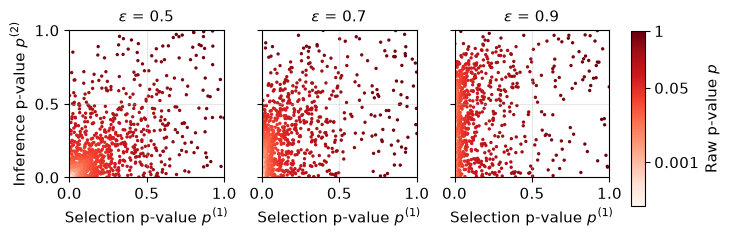

In [10]:

N_total = 1000
eps_list = [0.5, 0.7, 0.9]
mu = 2

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharex=True, sharey=True)

for i, eps in enumerate(eps_list):
    X = rng.normal(mu, 1, size=N_total)
    
    p = two_sided_pval(X)
    p1, p2 = pthin(p, epsilon=eps, rng=rng)
    # col = axes[i].scatter(p1, p2, marker='o', s=2, c=-np.log10(p), cmap='Reds', label='Null')
    col = axes[i].scatter(p1, p2, marker='o', s=2,
                      c=-np.log10(np.maximum(p, 0.0001)), cmap='Reds_r') # vmin=0, vmax=-np.log10(p).min()

    axes[i].set_title(f'$\\epsilon$ = {eps}', fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel(r'Selection p-value $p^{(1)}$', fontsize=11)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticks([0, 0.5, 1])
    axes[i].set_yticks([0, 0.5, 1])
    axes[i].tick_params(labelsize=11)

axes[0].set_ylabel(r'Inference p-value $p^{(2)}$')

plt.tight_layout()
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(col, cax=cax)

cbar.set_label('Raw p-value $p$', fontsize=11)
cbar.ax.invert_yaxis()
tick_pvals = [0.001, 0.05, 1]
cbar.set_ticks([-np.log10(t) for t in tick_pvals])
cbar.set_ticklabels([str(t) for t in tick_pvals], fontsize=11)

plt.savefig("../figures/p-val_dists.png", dpi=300, bbox_inches='tight')
plt.show()

## Conditional power

In [11]:
N_total = 10000
n_reps = 1
mus = np.linspace(0, 4, 5)
alpha = 0.05
eps = 0.5
test = one_sided_pval

results = {
    k: {"selected": [], "rejected": [], "uncond": []}
    for k in ["scheme1", "thinning", "csi"]
}

for mu in mus:
    counts = {
        k: {
            "selected": np.zeros(n_reps),
            "rejected": np.zeros(n_reps),
            "uncond": np.zeros(n_reps),
        }
        for k in results
    }

    for rep in range(n_reps):
        # Draw all observations at once
        X = rng.normal(mu, 1, size=N_total)  # (N_total,)
        p = test(X)  # (N_total,)

        # --- p-value thinning (uniform) ---
        p1, p2 = pthin(p, epsilon=eps, rng=rng)
        sel = p1 <= alpha
        counts["scheme1"]["selected"][rep] = sel.mean()
        counts["scheme1"]["rejected"][rep] = (
            (sel & (p2 <= alpha)).sum() / sel.sum() if sel.any() else np.nan
        )
        counts["scheme1"]["uncond"][rep] = (
            (sel & (p2 <= alpha)).sum() / N_total if sel.any() else 0
        )

        # # --- p-value carving ---
        # # Uses same selection event as thinning
        # counts["carving"]["selected"][rep] = sel.mean()
        # threshold = np.max([alpha ** 2, alpha ** (1 / (1 - eps))])
        # counts["carving"]["rejected"][rep] = (
        #     (sel & (p <= threshold)).sum() / sel.sum() if sel.any() else np.nan
        # )
        # counts["carving"]["uncond"][rep] = (
        #     (sel & (p <= threshold)).sum() / N_total if sel.any() else 0
        # )

        # --- Gaussian thinning ---
        gamma = np.sqrt((1 - eps) / eps)
        W = rng.normal(0, 1, size=N_total)
        X1 = (X + gamma * W) / np.sqrt(1 + gamma ** 2)
        X2 = (X - W / gamma) / np.sqrt(1 + 1 / gamma ** 2)
        p_g1 = test(X1)
        p_g2 = test(X2)
        sel = p_g1 <= alpha
        counts["thinning"]["selected"][rep] = sel.mean()
        counts["thinning"]["rejected"][rep] = (
            (sel & (p_g2 <= alpha)).sum() / sel.sum() if sel.any() else np.nan
        )
        counts["thinning"]["uncond"][rep] = (
            (sel & (p_g2 <= alpha)).sum() / N_total if sel.any() else 0
        )

        # --- Conditional ---
        sel = p <= alpha
        counts["csi"]["selected"][rep] = sel.mean()
        counts["csi"]["rejected"][rep] = (
            (sel & (p <= alpha**2)).sum() / sel.sum() if sel.any() else np.nan
        )
        counts["csi"]["uncond"][rep] = (
            (sel & (p <= alpha**2)).sum() / N_total if sel.any() else 0
        )

    for k in results:
        results[k]["selected"].append(np.nanmean(counts[k]["selected"]))
        results[k]["rejected"].append(np.nanmean(counts[k]["rejected"]))
        results[k]["uncond"].append(np.nanmean(counts[k]["uncond"]))

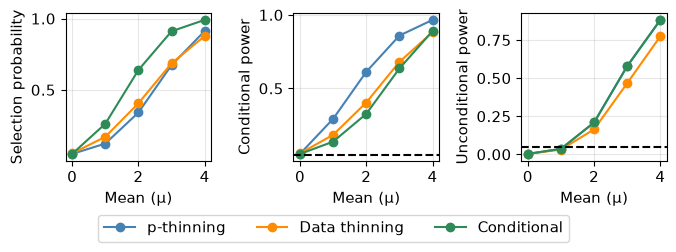

In [16]:
# Plot
labels = {
    'scheme1': 'p-thinning',
    # 'scheme2': 'Scheme 2 (mult noise)',
    'thinning': 'Data thinning',
    # 'scheme4': 'Scheme 4 (Z thinning)'
    'csi': 'Conditional',
    'carving': 'p-carving'
}
colors = {
    'scheme1': 'steelblue',
    'csi': 'seagreen',
    'thinning': 'darkorange',
    'carving': 'mediumpurple'
}

fig, axes = plt.subplots(1, 3, figsize=(7, 2.3))

for k in results:
    axes[0].plot(mus, results[k]['selected'], marker='o', label=labels[k], color=colors[k])  

axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Mean (μ)')
axes[0].set_ylabel('Selection probability')
axes[0].tick_params(labelsize=11)

for k in results:
    axes[1].plot(mus, results[k]['rejected'], marker='o', label=labels[k], color=colors[k])  

axes[1].grid(True, alpha=0.3)
axes[1].axhline(alpha, color='black', linestyle='--')
axes[1].set_xlabel('Mean (μ)')
axes[1].set_ylabel('Conditional power')
axes[1].tick_params(labelsize=11)

for k in results:
    axes[2].plot(mus, results[k]['uncond'], marker='o', label=labels[k], color=colors[k])   

axes[2].grid(True, alpha=0.3)
axes[2].axhline(alpha, color='black', linestyle='--')
axes[2].set_xlabel('Mean (μ)')
axes[2].set_ylabel('Unconditional power')
axes[2].tick_params(labelsize=11)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.07),
    ncol=len(results),
    frameon=True,
)

plt.tight_layout()
plt.savefig("../figures/filedrawer_testing.png", dpi=300, bbox_inches='tight')
plt.show()

## Winner's curse

In [17]:
def get_wc_results(N_total, n_reps, mus, gap_ratio, alpha):

    results = {
        k: {"selected": [], "rejected": []}
        for k in ["scheme1", "thinning", "csi", "carving"]
    }

    for mu in mus:
        counts = {
            k: {"selected": np.zeros(n_reps), "rejected": np.zeros(n_reps)}
            for k in results
        }

        for rep in range(n_reps):
            # Draw all observations at once
            X = rng.normal(0, 1, size=N_total)  # (N_total,)
            X[0] += mu
            X[1] += mu * gap_ratio
            p = two_sided_pval(X)  # (N_total,)

            # --- p-value thinning (uniform) ---
            p1, p2 = pthin(p, epsilon=0.5, rng=rng)
            sel = np.argmin(p1)
            counts["scheme1"]["selected"][rep] = sel == 0
            counts["scheme1"]["rejected"][rep] = p2[sel] <= alpha

            # --- p-value carving ---
            # Uses same selection event as thinning
            sel, near_winner = np.argpartition(p1, 2)[:2]
            threshold = np.max([alpha * p1[near_winner], alpha ** (1 / (0.5))])
            counts["carving"]["selected"][rep] = sel == 0
            counts["carving"]["rejected"][rep] = p[sel] <= threshold

            # --- Gaussian thinning ---
            eps = rng.normal(0, 1, size=N_total)
            X1 = (X + eps) / np.sqrt(2)
            X2 = (X - eps) / np.sqrt(2)
            p_g1 = two_sided_pval(X1)
            p_g2 = two_sided_pval(X2)
            sel = np.argmin(p_g1)
            counts["thinning"]["selected"][rep] = sel == 0
            counts["thinning"]["rejected"][rep] = p_g2[sel] <= alpha

            # --- Conditional ---
            sel, near_winner = np.argpartition(p, 2)[:2]
            counts["csi"]["selected"][rep] = sel == 0
            counts["csi"]["rejected"][rep] = p[sel] <= (alpha * p[near_winner])

        for k in results:
            results[k]["selected"].append(np.nanmean(counts[k]["selected"]))
            results[k]["rejected"].append(np.nanmean(counts[k]["rejected"]))

    return results

In [18]:
rng = np.random.default_rng(42)
n_reps = 1000
n_total = 10
mus = np.linspace(0, 4, 10)
alpha = 0.05

results_low = get_wc_results(n_total, n_reps, mus, 0, alpha)
results_med = get_wc_results(n_total, n_reps, mus, 0.5, alpha)
results_high = get_wc_results(n_total, n_reps, mus, 1, alpha)

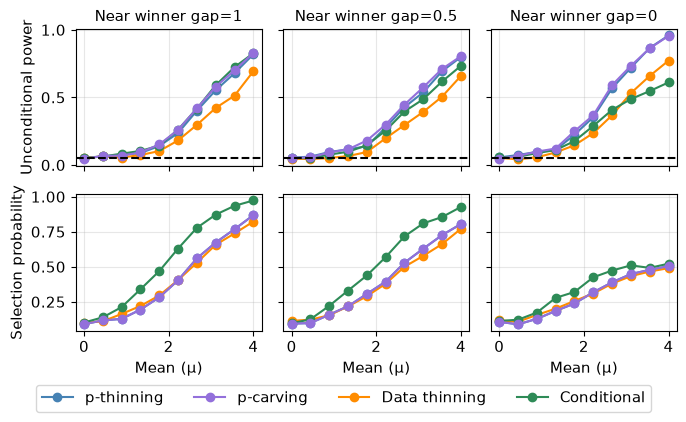

In [21]:
# Plot
labels = {
    'scheme1': 'p-thinning',
    # 'scheme2': 'Scheme 2 (mult noise)',
    'carving': 'p-carving',
    'thinning': 'Data thinning',
    # 'scheme4': 'Scheme 4 (Z thinning)'
    'csi': 'Conditional'
}
colors = {
    'scheme1': 'steelblue',
    'carving': 'mediumpurple',
    'csi': 'seagreen',
    'thinning': 'darkorange'
}

fig, axes = plt.subplots(2, 3, figsize=(7, 4), sharex=True, sharey='row')

# for i, results, n in zip([0, 1, 2], [results_low, results_med, results_high], [10, 1000, 100000]):
for i, results, n in zip([0, 1, 2], [results_low, results_med, results_high], [0, 0.5, 1]):

    for k in results:
        axes[0, i].plot(mus, results[k]['rejected'], marker='o', label=labels[k], color=colors[k]) 

    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axhline(alpha, color='black', linestyle='--')
    # axes[0, i].set_xlabel('Mean (μ)')
    axes[0, 0].set_ylabel('Unconditional power', fontsize=11)
    axes[0, i].tick_params(labelsize=11)
    axes[0, i].set_title(f'Near winner gap={1 - n}', fontsize=11)

    for k in results:
        axes[1, i].plot(mus, results[k]['selected'], marker='o', label=labels[k], color=colors[k])   

    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_xlabel('Mean (μ)', fontsize=11)
    axes[1, 0].set_ylabel('Selection probability', fontsize=11)
    axes[1, i].tick_params(labelsize=11)

handles, labels = axes[0, 0].get_legend_handles_labels()
order = [0, 3, 1, 2]
fig.legend(
    [handles[o] for o in order],
    [labels[o] for o in order],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=4,
    frameon=True,
    fontsize=11
)

plt.tight_layout()
plt.savefig("../figures/winners_testing.png", dpi=300, bbox_inches='tight')
plt.show()

## Analytical power

In [22]:
from scipy.integrate import quad

# Define the density of the p-value under the alternative
def f_p(q, mu):
    z = norm.ppf(1 - q)
    return np.exp(mu * z - mu**2 / 2)

# Define the integrand for the p-thinning denominator
def integrand(q, mu):
    return (q ** -0.5) * f_p(q, mu)

# Calculate conditional power for Data Thinning
def data_thinning_power(mu, alpha):
    z_1_minus_alpha = norm.ppf(1 - alpha)
    return norm.cdf(mu / np.sqrt(1.25) - z_1_minus_alpha)

# Calculate conditional power for p-thinning
def p_thinning_power(mu, alpha):
    z_1_minus_alpha2 = norm.ppf(1 - alpha**2)
    numerator = norm.cdf(mu - z_1_minus_alpha2)
    
    integral_val, _ = quad(integrand, alpha**2, 1, args=(mu,))
    denominator = numerator + (alpha / 2) * integral_val
    
    return numerator / denominator

# Setup parameters
mus = np.linspace(0, 4, 5)  # Can be increased (e.g., 50) for a smoother curve
alphas = [0.01, 0.05, 0.1]

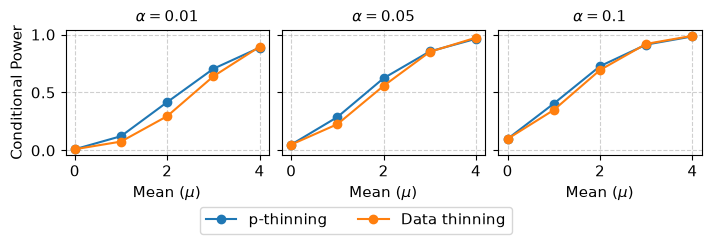

In [23]:
# Set font size globally
plt.rcParams.update({'font.size': 11})

# Create the 3-panel horizontal plot
fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True, constrained_layout=True)

# Plotting loop
for i, alpha in enumerate(alphas):
    ax = axes[i]
    
    p_thin_vals = [p_thinning_power(mu, alpha) for mu in mus]
    d_thin_vals = [data_thinning_power(mu, alpha) for mu in mus]
    
    # p-thinning is blue, data thinning is orange
    ax.plot(mus, p_thin_vals, color='tab:blue', marker='o', label='p-thinning')
    ax.plot(mus, d_thin_vals, color='tab:orange', marker='o', label='Data thinning')
    
    ax.set_title(rf'$\alpha = {alpha}$', fontsize=11)
    ax.set_xlabel(r'Mean ($\mu$)')
    ax.grid(True, linestyle='--', alpha=0.6)

# Set the y-axis label on the first panel only
axes[0].set_ylabel('Conditional Power')

# Add a single shared legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True)

# Show/save the plot
plt.savefig("../figures/filedrawer_analytical_power.png", dpi=300, bbox_inches='tight')
plt.show()

## Winners t-test

In [ ]:
from scipy.stats import ttest_1samp
N_total = 100
n_reps = 500
d = 10
mus = np.linspace(0, 4, 5)
alpha = 0.05
test = lambda x: ttest_1samp(x.T, 0).pvalue

results = {k: {'selected': [], 'rejected': []} for k in ['scheme1', 'ss']}
    
for mu in mus:
    counts = {k: {'selected': np.zeros(n_reps), 'rejected': np.zeros(n_reps)} for k in results}

    for rep in range(n_reps):
        # Draw all observations at once
        X = rng.normal(0, 1, size=(N_total, d))          # (N_total,)
        # p = test(X)                         # (N_total,)
        X[i] += mu
        # --- p-value thinning (uniform) ---
        p = test(X)
        p1, p2 = pthin(p, epsilon=0.5, rng=rng)
        sel = np.argmin(p1)
        counts['scheme1']['selected'][rep] = (sel == 0)
        counts['scheme1']['rejected'][rep] = (p2[sel] <= alpha)

        # --- Gaussian thinning ---
        eps = rng.normal(0, 1, size=N_total)
        X1 = X[:, :d//2]
        X2 = X[:, d//2:]
        p1 = test(X1)
        p2 = test(X2)
        sel = np.argmin(p1)
        counts['ss']['selected'][rep] = (sel == 0)
        counts['ss']['rejected'][rep] = (p2[sel] <= alpha)

    for k in results:
        results[k]['selected'].append(np.nanmean(counts[k]['selected']))
        results[k]['rejected'].append(np.nanmean(counts[k]['rejected']))

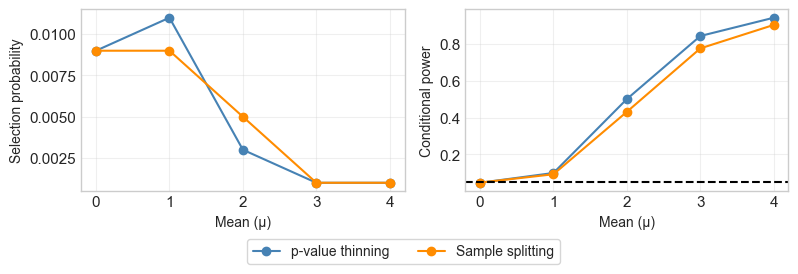

In [148]:
# Plot
labels = {
    'scheme1': 'p-value thinning',
    # 'scheme2': 'Scheme 2 (mult noise)',
    'ss': 'Sample splitting',
    # 'scheme4': 'Scheme 4 (Z thinning)'
    'csi': 'Conditional',
    'bh': 'BH'
}
colors = {
    'scheme1': 'steelblue',
    'csi': 'seagreen',
    'ss': 'darkorange',
    'BH': 'mediumpurple'
}

fig, axes = plt.subplots(1, 2, figsize=(8, 2.5))

for k in results:
    axes[0].plot(mus, results[k]['selected'], marker='o', label=labels[k], color=colors[k])  

axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Mean (μ)')
axes[0].set_ylabel('Selection probability')
axes[0].tick_params(labelsize=11)

for k in results:
    axes[1].plot(mus, results[k]['rejected'], marker='o', label=labels[k], color=colors[k])  

axes[1].grid(True, alpha=0.3)
axes[1].axhline(alpha, color='black', linestyle='--')
axes[1].set_xlabel('Mean (μ)')
axes[1].set_ylabel('Conditional power')
axes[1].tick_params(labelsize=11)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=3,
    frameon=True,
)

plt.tight_layout()
plt.show()